## Probar con DOC1
## Se usa la imagen con la curva y la señal de cruce de color amarillo esperando que se distinga entre las demas

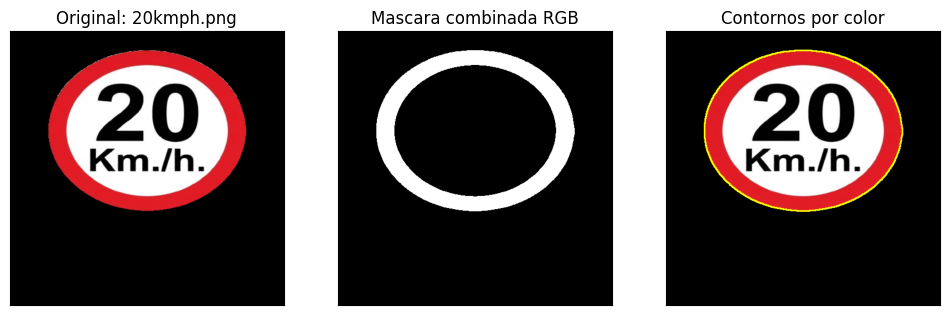

20kmph.png -> azul: 0 rojo: 1 amarillo: 0


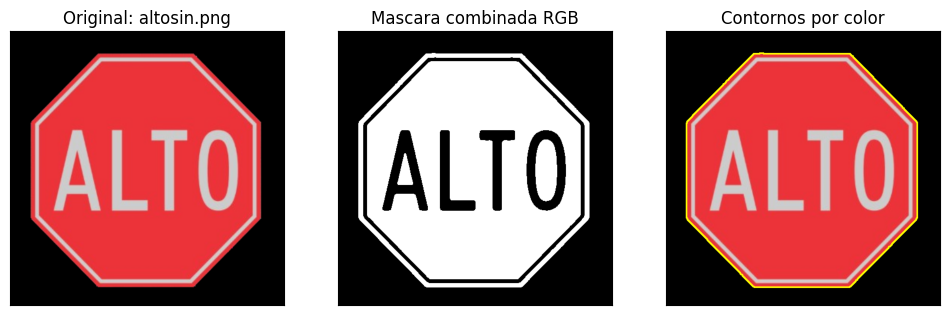

altosin.png -> azul: 0 rojo: 1 amarillo: 0


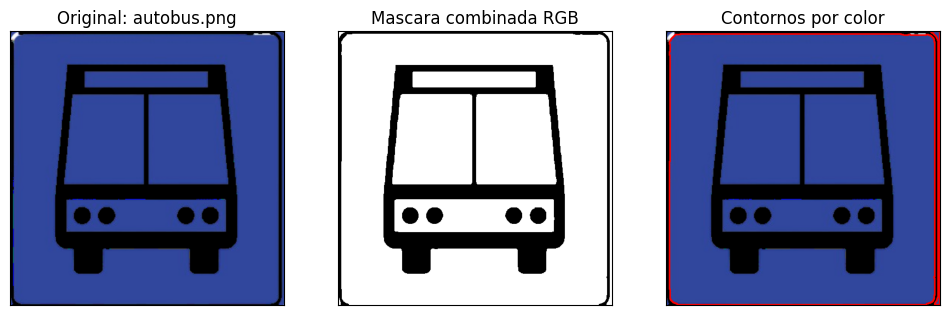

autobus.png -> azul: 4 rojo: 0 amarillo: 0


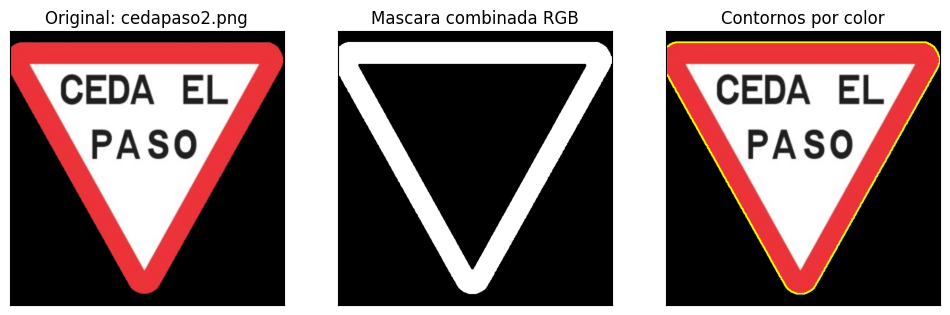

cedapaso2.png -> azul: 0 rojo: 1 amarillo: 0


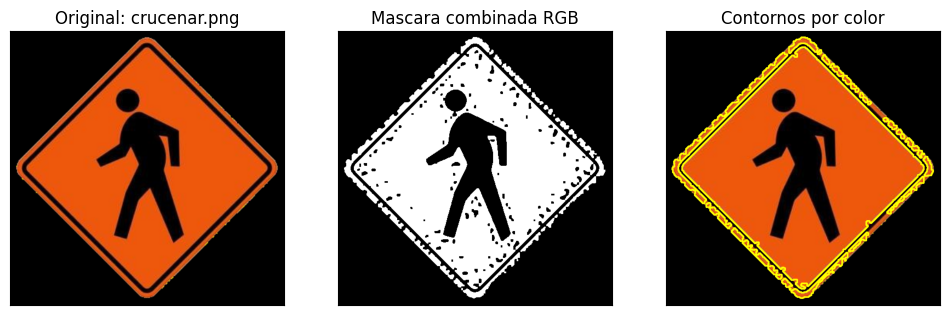

crucenar.png -> azul: 0 rojo: 19 amarillo: 0


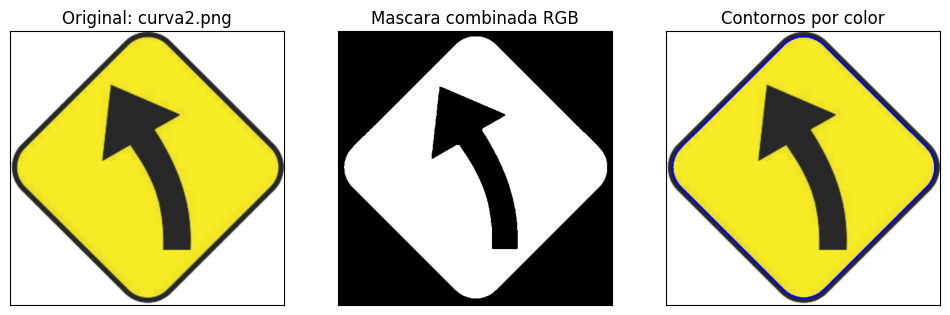

curva2.png -> azul: 0 rojo: 0 amarillo: 1


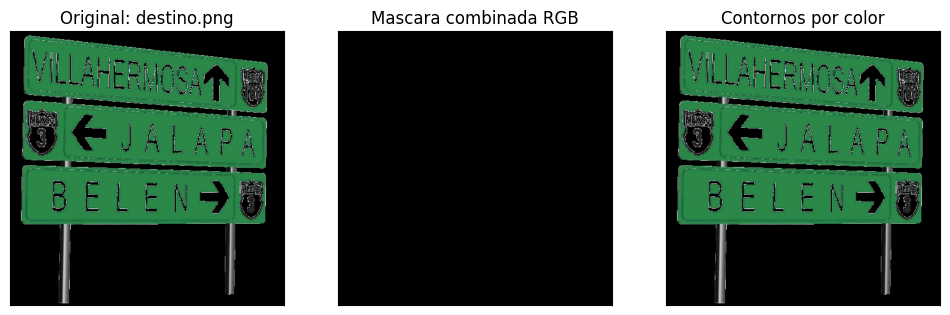

destino.png -> azul: 0 rojo: 0 amarillo: 0


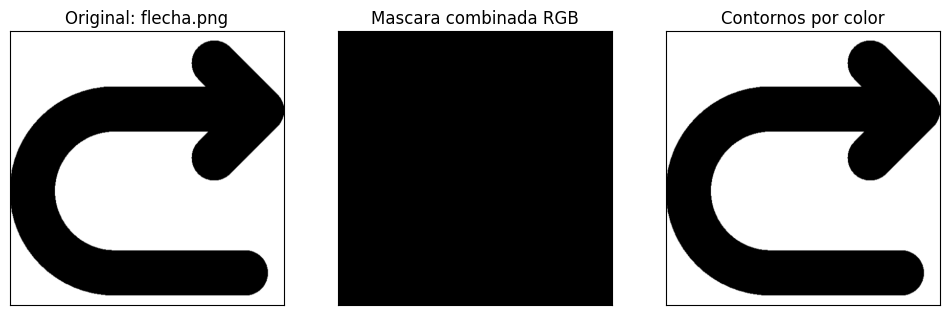

flecha.png -> azul: 0 rojo: 0 amarillo: 0


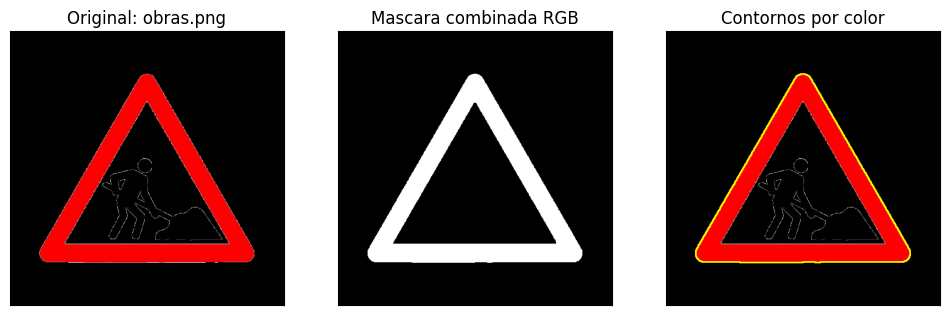

obras.png -> azul: 0 rojo: 1 amarillo: 0


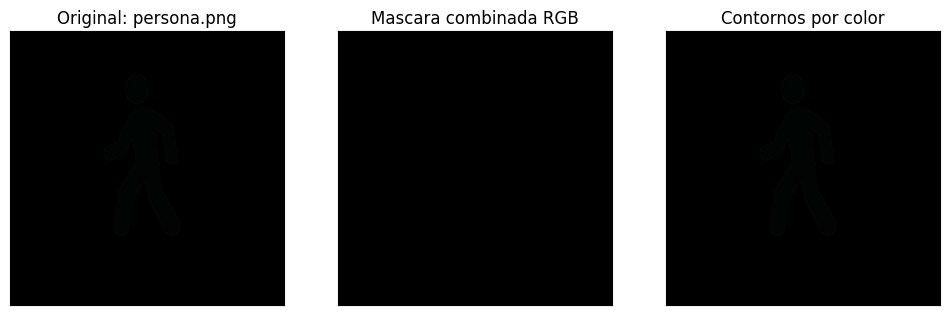

persona.png -> azul: 0 rojo: 0 amarillo: 0


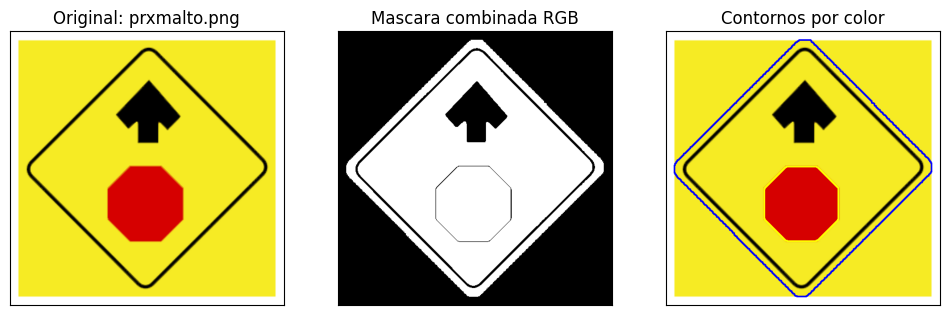

prxmalto.png -> azul: 0 rojo: 1 amarillo: 1


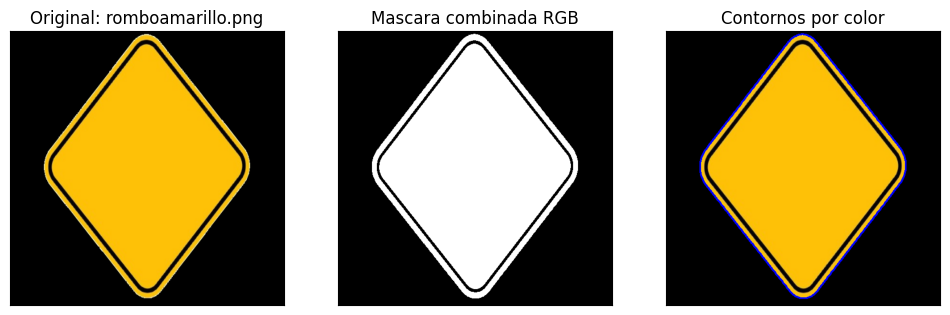

romboamarillo.png -> azul: 0 rojo: 0 amarillo: 1


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Carpeta de imagenes sin fondo
carpeta='img/sinfondo'
imagenes=sorted(glob.glob(os.path.join(carpeta,'*.png')))
# Quita imagen anterior de cruce y deja la nueva crucenar
imagenes=[r for r in imagenes if ('cruce' not in os.path.basename(r).lower()) or ('crucenar' in os.path.basename(r).lower())]

# Rangos HSV ajustados (igual que Detectar_colores)
azul_b=np.array([85,70,60],np.uint8)
azul_a=np.array([135,255,255],np.uint8)
amarillo_b=np.array([18,70,70],np.uint8)
amarillo_a=np.array([40,255,255],np.uint8)
rojo_b1=np.array([0,100,70],np.uint8)
rojo_a1=np.array([10,255,255],np.uint8)
rojo_b2=np.array([170,100,70],np.uint8)
rojo_a2=np.array([180,255,255],np.uint8)

# Kernel y umbral de area
kernel=np.ones((3,3),np.uint8)
min_area=120

for ruta in imagenes:
    img=cv2.imread(ruta,cv2.IMREAD_UNCHANGED)
    if img is None:
        print('No se pudo leer:',ruta)
        continue

    # Si tiene alpha, se procesa en BGR manteniendo el objeto principal
    if len(img.shape)==3 and img.shape[2]==4:
        bgr=img[:,:,:3].copy()
        alpha=img[:,:,3]
    else:
        bgr=img.copy()
        alpha=None

    bgr=cv2.resize(bgr,(500,500))
    frame_s=cv2.GaussianBlur(bgr,(7,7),0)
    hsv=cv2.cvtColor(frame_s,cv2.COLOR_BGR2HSV)

    # Mascaras por color
    mask_azul=cv2.inRange(hsv,azul_b,azul_a)
    mask_amarillo=cv2.inRange(hsv,amarillo_b,amarillo_a)
    mask_rojo=cv2.bitwise_or(cv2.inRange(hsv,rojo_b1,rojo_a1),cv2.inRange(hsv,rojo_b2,rojo_a2))

    # Si habia alpha, limitar deteccion al objeto
    if alpha is not None:
        alpha=cv2.resize(alpha,(500,500))
        _,mask_obj=cv2.threshold(alpha,1,255,cv2.THRESH_BINARY)
        mask_azul=cv2.bitwise_and(mask_azul,mask_obj)
        mask_amarillo=cv2.bitwise_and(mask_amarillo,mask_obj)
        mask_rojo=cv2.bitwise_and(mask_rojo,mask_obj)

    # Limpieza morfologica
    mask_azul=cv2.morphologyEx(mask_azul,cv2.MORPH_OPEN,kernel)
    mask_azul=cv2.morphologyEx(mask_azul,cv2.MORPH_CLOSE,kernel)
    mask_amarillo=cv2.morphologyEx(mask_amarillo,cv2.MORPH_OPEN,kernel)
    mask_amarillo=cv2.morphologyEx(mask_amarillo,cv2.MORPH_CLOSE,kernel)
    mask_rojo=cv2.morphologyEx(mask_rojo,cv2.MORPH_OPEN,kernel)
    mask_rojo=cv2.morphologyEx(mask_rojo,cv2.MORPH_CLOSE,kernel)

    # Contornos por color
    cont_azul,_=cv2.findContours(mask_azul,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cont_amarillo,_=cv2.findContours(mask_amarillo,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cont_rojo,_=cv2.findContours(mask_rojo,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    salida=bgr.copy()

    # Azul -> contorno rojo
    for c in cont_azul:
        area=cv2.contourArea(c)
        if area>min_area:
            cv2.drawContours(salida,[c],-1,(0,0,255),2)

    # Rojo -> contorno amarillo
    for c in cont_rojo:
        area=cv2.contourArea(c)
        if area>min_area:
            cv2.drawContours(salida,[c],-1,(0,255,255),2)

    # Amarillo -> contorno azul
    for c in cont_amarillo:
        area=cv2.contourArea(c)
        if area>min_area:
            cv2.drawContours(salida,[c],-1,(255,0,0),2)

    # Visualizacion
    nombre=os.path.basename(ruta)
    bgr_rgb=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
    salida_rgb=cv2.cvtColor(salida,cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(bgr_rgb,vmin=0,vmax=255)
    plt.title(f'Original: {nombre}')
    plt.xticks([])
    plt.yticks([])

    plt.subplot(1,3,2)
    mezcla=cv2.add(mask_rojo,cv2.add(mask_amarillo,mask_azul))
    plt.imshow(mezcla,vmin=0,vmax=255,cmap='gray')
    plt.title('Mascara combinada RGB')
    plt.xticks([])
    plt.yticks([])

    plt.subplot(1,3,3)
    plt.imshow(salida_rgb,vmin=0,vmax=255)
    plt.title('Contornos por color')
    plt.xticks([])
    plt.yticks([])

    plt.show()

    print(nombre,'-> azul:',len(cont_azul),'rojo:',len(cont_rojo),'amarillo:',len(cont_amarillo))

In [ ]:
import numpy as np
import cv2

# Deteccion en tiempo real por camara con clasificacion de senales
cam=cv2.VideoCapture(0)

if not cam.isOpened():
    print('No se pudo abrir la camara')
else:
    # Rangos HSV
    azul_b=np.array([85,70,60],np.uint8)
    azul_a=np.array([135,255,255],np.uint8)

    amarillo_b=np.array([18,70,70],np.uint8)
    amarillo_a=np.array([40,255,255],np.uint8)

    # Naranja para CRUCENAR
    naranja_b=np.array([6,90,80],np.uint8)
    naranja_a=np.array([22,255,255],np.uint8)

    rojo_b1=np.array([0,100,70],np.uint8)
    rojo_a1=np.array([10,255,255],np.uint8)
    rojo_b2=np.array([170,100,70],np.uint8)
    rojo_a2=np.array([180,255,255],np.uint8)

    verde_b=np.array([35,60,60],np.uint8)
    verde_a=np.array([90,255,255],np.uint8)

    negro_b=np.array([0,0,0],np.uint8)
    negro_a=np.array([180,255,100],np.uint8)

    kernel=np.ones((3,3),np.uint8)
    min_area=450

    while True:
        ret,frame=cam.read()
        if not ret:
            break

        h_frame,w_frame=frame.shape[:2]

        # Cuadro central de deteccion (solo esta zona)
        x1=int(w_frame*0.25)
        y1=int(h_frame*0.20)
        x2=int(w_frame*0.75)
        y2=int(h_frame*0.80)

        roi=frame[y1:y2,x1:x2].copy()

        frame_s=cv2.GaussianBlur(roi,(7,7),0)
        hsv=cv2.cvtColor(frame_s,cv2.COLOR_BGR2HSV)

        # Mascaras por color
        mask_azul=cv2.inRange(hsv,azul_b,azul_a)
        mask_amarillo=cv2.inRange(hsv,amarillo_b,amarillo_a)
        mask_naranja=cv2.inRange(hsv,naranja_b,naranja_a)
        mask_rojo=cv2.bitwise_or(cv2.inRange(hsv,rojo_b1,rojo_a1),cv2.inRange(hsv,rojo_b2,rojo_a2))
        mask_verde=cv2.inRange(hsv,verde_b,verde_a)
        mask_negro=cv2.inRange(hsv,negro_b,negro_a)

        # Limpieza morfologica
        mask_azul=cv2.morphologyEx(mask_azul,cv2.MORPH_OPEN,kernel)
        mask_azul=cv2.morphologyEx(mask_azul,cv2.MORPH_CLOSE,kernel)

        mask_amarillo=cv2.morphologyEx(mask_amarillo,cv2.MORPH_OPEN,kernel)
        mask_amarillo=cv2.morphologyEx(mask_amarillo,cv2.MORPH_CLOSE,kernel)

        mask_naranja=cv2.morphologyEx(mask_naranja,cv2.MORPH_OPEN,kernel)
        mask_naranja=cv2.morphologyEx(mask_naranja,cv2.MORPH_CLOSE,kernel)

        mask_rojo=cv2.morphologyEx(mask_rojo,cv2.MORPH_OPEN,kernel)
        mask_rojo=cv2.morphologyEx(mask_rojo,cv2.MORPH_CLOSE,kernel)

        mask_verde=cv2.morphologyEx(mask_verde,cv2.MORPH_OPEN,kernel)
        mask_verde=cv2.morphologyEx(mask_verde,cv2.MORPH_CLOSE,kernel)

        mask_negro=cv2.morphologyEx(mask_negro,cv2.MORPH_OPEN,kernel)
        mask_negro=cv2.morphologyEx(mask_negro,cv2.MORPH_CLOSE,kernel)

        # Unir rectangulos verdes cercanos (para no detectar 3 destinos separados)
        mask_verde_union=cv2.dilate(mask_verde,np.ones((9,9),np.uint8),iterations=1)
        mask_verde_union=cv2.morphologyEx(mask_verde_union,cv2.MORPH_CLOSE,np.ones((11,11),np.uint8))

        # Buscar contornos
        cont_azul,_=cv2.findContours(mask_azul,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cont_amarillo,_=cv2.findContours(mask_amarillo,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cont_naranja,_=cv2.findContours(mask_naranja,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cont_rojo,_=cv2.findContours(mask_rojo,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cont_verde,_=cv2.findContours(mask_verde_union,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

        # Exclusividad: si aparece ALTO PROXIMO, no mostrar CRUCE en el mismo frame
        hay_alto_proximo=False

        # 1) AZUL -> AUTOBUS (mostrar una sola vez)
        mejor_azul=None
        area_azul_max=0
        for c in cont_azul:
            area=cv2.contourArea(c)
            if area>min_area and area>area_azul_max:
                area_azul_max=area
                mejor_azul=c

        if mejor_azul is not None:
            x,y,w,h=cv2.boundingRect(mejor_azul)
            precision=min(99,int(60+(area_azul_max/1800)))
            cv2.drawContours(roi,[mejor_azul],-1,(0,0,255),3)
            cv2.putText(roi,'AUTOBUS '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.62,(0,0,255),2)

        # 2) ROJO -> ALTO / CEDA EL PASO / 20KMH
        for c in cont_rojo:
            area=cv2.contourArea(c)
            if area<=min_area:
                continue

            per=cv2.arcLength(c,True)
            if per<=0:
                continue

            ap=cv2.approxPolyDP(c,0.02*per,True)
            lados=len(ap)
            x,y,w,h=cv2.boundingRect(c)
            asp=w/float(h) if h>0 else 0.0
            circ=(4*np.pi*area)/(per*per)

            _,radio=cv2.minEnclosingCircle(c)
            fill_circ=0.0
            if radio>0:
                fill_circ=area/(np.pi*radio*radio)

            etiqueta=''
            precision=0

            # 20KMH: circulo casi perfecto (estricto)
            if circ>0.88 and 0.92<asp<1.08 and fill_circ>0.94 and lados>=8:
                etiqueta='20KMH'
                precision=int(min(99,(circ*55)+(fill_circ*45)))

            # ALTO: octagono de lineas (evitar forma circular)
            elif 7<=lados<=9 and 0.70<asp<1.30 and 0.45<circ<0.84 and fill_circ<0.90:
                etiqueta='ALTO'
                p_lados=100-abs(8-lados)*8
                p_circ=int(min(100,max(0,(0.84-circ)*260)))
                precision=max(70,min(99,int((p_lados+p_circ)/2)))

            # CEDA EL PASO: triangulo invertido rojo
            elif lados==3:
                pts=ap.reshape(-1,2)
                ys=np.sort(pts[:,1])
                if abs(int(ys[0])-int(ys[1])) < (0.20*h) and abs(int(ys[2])-int(ys[1])) > (0.25*h):
                    etiqueta='CEDA EL PASO'
                    precision=90

            cv2.drawContours(roi,[c],-1,(0,255,255),3)
            if etiqueta!='':
                cv2.putText(roi,etiqueta+' '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.58,(0,255,255),2)

        # 3) AMARILLO (ROMBO) -> CURVA / ALTO PROXIMO
        for c in cont_amarillo:
            area=cv2.contourArea(c)
            if area<=min_area:
                continue

            per=cv2.arcLength(c,True)
            if per<=0:
                continue

            ap=cv2.approxPolyDP(c,0.02*per,True)
            lados=len(ap)
            x,y,w,h=cv2.boundingRect(c)
            asp=w/float(h) if h>0 else 0.0

            # Solo rombos aproximados
            if not (lados==4 and 0.70<asp<1.35):
                continue

            # ROI interno para buscar simbolos
            xi=max(x+int(0.16*w),0)
            yi=max(y+int(0.16*h),0)
            xf=min(x+int(0.84*w),roi.shape[1])
            yf=min(y+int(0.84*h),roi.shape[0])
            if xf<=xi or yf<=yi:
                continue

            roi_neg=mask_negro[yi:yf,xi:xf]
            roi_rojo=mask_rojo[yi:yf,xi:xf]

            h_in,w_in=roi_neg.shape[:2]
            area_in=float(h_in*w_in)
            if area_in<=0:
                continue

            # Medicion de borde negro externo vs centro negro
            cont_mask=np.zeros((h_in,w_in),np.uint8)
            cv2.drawContours(cont_mask,[ap-np.array([[[xi,yi]]])],-1,255,-1)

            k=max(2,int(min(w_in,h_in)*0.07))
            ker_in=np.ones((k,k),np.uint8)
            inner=cv2.erode(cont_mask,ker_in,iterations=1)
            ring=cv2.subtract(cont_mask,inner)

            ring_px=max(1,cv2.countNonZero(ring))
            inner_px=max(1,cv2.countNonZero(inner))
            black_ring=cv2.countNonZero(cv2.bitwise_and(roi_neg,ring))/float(ring_px)
            black_inner=cv2.countNonZero(cv2.bitwise_and(roi_neg,inner))/float(inner_px)

            # Simbolo negro principal
            cont_neg,_=cv2.findContours(roi_neg,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
            neg_tri=False
            neg_circ=False
            flecha_grande=False
            precision_neg=0

            if len(cont_neg)>0:
                cneg=max(cont_neg,key=cv2.contourArea)
                a_neg=cv2.contourArea(cneg)
                ratio_neg=a_neg/area_in
                if ratio_neg>0.02:
                    p_neg=cv2.arcLength(cneg,True)
                    if p_neg>0:
                        ap_neg=cv2.approxPolyDP(cneg,0.03*p_neg,True)
                        lados_neg=len(ap_neg)
                        xg,yg,wg,hg=cv2.boundingRect(cneg)
                        asp_neg=wg/float(hg) if hg>0 else 0.0
                        circ_neg=(4*np.pi*a_neg)/(p_neg*p_neg)

                        if ratio_neg>0.10 and 0.30<asp_neg<1.20:
                            flecha_grande=True

                        if lados_neg==3:
                            neg_tri=True
                        elif circ_neg>0.72 and 0.75<asp_neg<1.25:
                            neg_circ=True

                        precision_neg=int(min(98,60+(ratio_neg*260)))

            # Simbolo rojo principal (para ALTO PROXIMO)
            cont_rin,_=cv2.findContours(roi_rojo,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
            rojo_oct=False
            precision_rojo=0

            if len(cont_rin)>0:
                cr=max(cont_rin,key=cv2.contourArea)
                a_r=cv2.contourArea(cr)
                if a_r>area_in*0.025:
                    p_r=cv2.arcLength(cr,True)
                    if p_r>0:
                        ap_r=cv2.approxPolyDP(cr,0.03*p_r,True)
                        lados_r=len(ap_r)
                        xr,yr,wr,hr=cv2.boundingRect(cr)
                        asp_r=wr/float(hr) if hr>0 else 0.0
                        circ_r=(4*np.pi*a_r)/(p_r*p_r)
                        if 7<=lados_r<=9 and 0.72<asp_r<1.28 and 0.55<circ_r<0.92:
                            rojo_oct=True
                            precision_rojo=93

            # Amarillo claro: ALTO PROXIMO suele verse mas claro
            y_mask_local=mask_amarillo[yi:yf,xi:xf]
            roi_hsv=hsv[yi:yf,xi:xf]
            pix_y=roi_hsv[:,:,2][y_mask_local>0]
            v_mean=float(np.mean(pix_y)) if pix_y.size>0 else 0.0
            amarillo_claro=(v_mean>145)

            etiqueta=''
            precision=0

            # Si hay rojo al centro: es si o si ALTO PROXIMO
            if rojo_oct:
                etiqueta='ALTO PROXIMO'
                precision=max(86,precision_rojo)
                hay_alto_proximo=True

            # Refuerzo para amarillos claros de ALTO PROXIMO
            elif amarillo_claro and black_ring>0.05 and black_inner<0.55:
                etiqueta='ALTO PROXIMO'
                precision=82
                hay_alto_proximo=True

            # CURVA
            elif flecha_grande or neg_tri or neg_circ:
                etiqueta='CURVA'
                precision=max(76,precision_neg)

            cv2.drawContours(roi,[c],-1,(255,0,0),3)
            if etiqueta!='':
                cv2.putText(roi,etiqueta+' '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.58,(255,0,0),2)

        # 3B) NARANJA (ROMBO) -> CRUCENAR
        mejor_naranja=None
        area_naranja_max=0
        for c in cont_naranja:
            area=cv2.contourArea(c)
            if area<=min_area:
                continue
            per=cv2.arcLength(c,True)
            if per<=0:
                continue
            ap=cv2.approxPolyDP(c,0.02*per,True)
            lados=len(ap)
            x,y,w,h=cv2.boundingRect(c)
            asp=w/float(h) if h>0 else 0.0
            if lados==4 and 0.70<asp<1.35 and area>area_naranja_max:
                area_naranja_max=area
                mejor_naranja=c

        if mejor_naranja is not None and not hay_alto_proximo:
            x,y,w,h=cv2.boundingRect(mejor_naranja)

            # Si en este rombo detectamos rojo interno, priorizar ALTO PROXIMO
            xi=max(x+int(0.18*w),0)
            yi=max(y+int(0.18*h),0)
            xf=min(x+int(0.82*w),roi.shape[1])
            yf=min(y+int(0.82*h),roi.shape[0])
            roi_rojo_n=mask_rojo[yi:yf,xi:xf]
            area_n_in=float(max(1,(yf-yi)*(xf-xi)))
            rojo_ratio_n=cv2.countNonZero(roi_rojo_n)/area_n_in if area_n_in>0 else 0.0

            if rojo_ratio_n>0.03:
                precision=min(99,int(84+(rojo_ratio_n*180)))
                cv2.drawContours(roi,[mejor_naranja],-1,(255,0,0),3)
                cv2.putText(roi,'ALTO PROXIMO '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.58,(255,0,0),2)
                hay_alto_proximo=True
            else:
                precision=min(99,int(72+(area_naranja_max/2300)))
                cv2.drawContours(roi,[mejor_naranja],-1,(255,0,0),3)
                cv2.putText(roi,'CRUCE '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.58,(255,0,0),2)

        # 4) VERDE -> DESTINO (mostrar una sola vez, agrupado)
        mejor_verde=None
        area_verde_max=0
        for c in cont_verde:
            area=cv2.contourArea(c)
            if area>min_area and area>area_verde_max:
                area_verde_max=area
                mejor_verde=c

        if mejor_verde is not None:
            x,y,w,h=cv2.boundingRect(mejor_verde)
            m=8
            x=max(0,x-m)
            y=max(0,y-m)
            w=min(roi.shape[1]-x,w+2*m)
            h=min(roi.shape[0]-y,h+2*m)
            precision=min(99,int(65+(area_verde_max/2200)))
            cv2.rectangle(roi,(x,y),(x+w,y+h),(0,255,0),3)
            cv2.putText(roi,'DESTINO '+str(precision)+'%',(x,y-8),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

        # Pegar ROI procesada y dibujar cuadro guia
        frame[y1:y2,x1:x2]=roi
        cv2.rectangle(frame,(x1,y1),(x2,y2),(255,255,0),2)

        cv2.imshow('Deteccion por camara - ProyectoExitoso',frame)

        # Presiona 0 para salir
        if cv2.waitKey(1)&0xFF==ord('0'):
            break

cam.release()
cv2.destroyAllWindows()